In [1]:
! pip install pandas matplotlib numpy tensorflow scikit-learn
! pip install nvidia-cudnn-cu12==9.3.0.75

In [ ]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Input, Add, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from boxe_utils import DEFAULT_VIDEOS, load_video, add_velocity_and_acceleration

os.chdir("/lapix/privado/boxe.ml")


I0000 00:00:1780585086.710987  268074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780585086.782247  268074 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780585088.349731  268074 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
all_videos = DEFAULT_VIDEOS

X_all, y_all_raw = [], []

for video in all_videos:
    skeleton, labels_raw = load_video(video)
    X_all.append(skeleton)
    y_all_raw.append(labels_raw)

X_all = np.concatenate(X_all)
y_all_raw = np.concatenate(y_all_raw)

print("Shape total:", X_all.shape)
print("Total amostras:", len(y_all_raw))

Shape total: (4766, 25, 17, 2)
Total amostras: 4766


In [ ]:
# Encoding de labels
classes = sorted(np.unique(y_all_raw))
label_to_id = {label: idx for idx, label in enumerate(classes)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

y_all = np.array([label_to_id[x] for x in y_all_raw])

print("Classes:", classes)
print("Distribuição:")
unique, counts = np.unique(y_all, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

num_classes = len(classes)

Classes: ['Cross', 'Jab', 'Lead Hook', 'Lead Uppercut', 'Rear Hook', 'Rear Uppercut']
Distribuição:
  Cross: 1371
  Jab: 1287
  Lead Hook: 910
  Lead Uppercut: 428
  Rear Hook: 297
  Rear Uppercut: 473


In [ ]:
# Reshape
X_all = X_all.reshape(X_all.shape[0], 25, 34)
print("Shape após reshape:", X_all.shape)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print("Treino:", X_tr.shape, "| Distribuição:", np.bincount(y_tr))
print("Teste: ", X_te.shape, "| Distribuição:", np.bincount(y_te))

Shape após reshape: (4766, 25, 34)
Treino: (3812, 25, 34) | Distribuição: [1097 1029  728  342  238  378]
Teste:  (954, 25, 34) | Distribuição: [274 258 182  86  59  95]


In [ ]:
# Normalização global (fit só no treino, aplica em ambos)
X_mean_global = X_tr.mean()
X_std_global  = X_tr.std() + 1e-8

X_tr_norm = (X_tr - X_mean_global) / X_std_global
X_te_norm = (X_te - X_mean_global) / X_std_global

print("Normalização aplicada")
print(f"  Treino — min: {X_tr_norm.min():.3f}, max: {X_tr_norm.max():.3f}")
print(f"  Teste  — min: {X_te_norm.min():.3f}, max: {X_te_norm.max():.3f}")

Normalização aplicada
  Treino — min: -0.720, max: 3.571
  Teste  — min: -0.720, max: 3.289


In [ ]:
# Adicionar velocidade e aceleração
# X shape: (N, 25, 34) → saída: (N, 25, 102)
# Os 34 features originais são posição dos keypoints
# Velocidade = diferença entre frames consecutivos (como o soco se move)
# Aceleração = diferença da velocidade (quão rápido muda a direção)
# Isso ajuda a distinguir Cross de Jab, que têm trajetórias parecidas mas velocidades diferentes

def add_velocity_and_acceleration(X):
    vel = np.diff(X, axis=1, prepend=X[:, :1, :])   # (N, 25, 34)
    acc = np.diff(vel, axis=1, prepend=vel[:, :1, :]) # (N, 25, 34)
    return np.concatenate([X, vel, acc], axis=-1)     # (N, 25, 102)

X_tr_feat = add_velocity_and_acceleration(X_tr_norm)
X_te_feat = add_velocity_and_acceleration(X_te_norm)

print("Shape com velocidade e aceleração:", X_tr_feat.shape)  # (N, 25, 102)

Shape com velocidade e aceleração: (3812, 25, 102)


In [ ]:
# Data augmentation (só no treino)
def augment_skeleton(X, noise_std=0.02, flip_prob=0.5):
    X_aug = X.copy()
    X_aug += np.random.normal(0, noise_std, X_aug.shape)
    flip_mask = np.random.rand(len(X_aug)) < flip_prob
    X_aug[flip_mask, :, 0::2] = -X_aug[flip_mask, :, 0::2]  # espelha coords x
    return X_aug

X_tr_aug  = augment_skeleton(X_tr_feat)
X_tr_final = np.concatenate([X_tr_feat, X_tr_aug])
y_tr_final = np.concatenate([y_tr, y_tr])

print("Treino com augmentation:", X_tr_final.shape)

Treino com augmentation: (7624, 25, 102)


In [ ]:
# Construir modelo
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs)

model = build_model(input_shape=(25, 102), num_classes=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1780585114.590446  268074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 74561 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:1b:00.0, compute capability: 9.0a
I0000 00:00:1780585114.602761  268074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 2123 MB memory:  -> device: 1, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:43:00.0, compute capability: 9.0a
I0000 00:00:1780585114.633266  268074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 78754 MB memory:  -> device: 2, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:52:00.0, compute capability: 9.0a
I0000 00:00:1780585114.645006  268074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 78758 MB memory:  -> device: 3, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:61:00.0, compute capability: 9.0a
I0000 00:00:1780585114.662234  268074 gpu_device.cc:2043] Cre

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 25, 102)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 25, 256)   │    236,544 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 256)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 25, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 25, 128)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 128)   │     66,048 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        774 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 484,998 (1.85 MB)

 Trainable params: 484,742 (1.85 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# Class weights e callbacks
weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr_final)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        mode="max",
        verbose=1
    ),
    ModelCheckpoint(
        "best_model_v2.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

Class weights: {0: 0.5791552719538134, 1: 0.6174279235503726, 2: 0.8727106227106227, 3: 1.857699805068226, 4: 2.669467787114846, 5: 1.6807760141093475}


In [ ]:
# Treinar
history = model.fit(
    X_tr_final, y_tr_final,
    validation_data=(X_te_feat, y_te),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


I0000 00:00:1780585128.477794  268691 cuda_dnn.cc:461] Loaded cuDNN version 90300


237/239 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2253 - loss: 2.0905
Epoch 1: val_accuracy improved from None to 0.44969, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.2626 - loss: 1.9223 - val_accuracy: 0.4497 - val_loss: 1.4450 - learning_rate: 0.0010
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3884 - loss: 1.6370
Epoch 2: val_accuracy improved from 0.44969 to 0.56289, saving model to best_model_v2.keras

Epoch 2: finished saving model to best_model_v2.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3997 - loss: 1.5899 - val_accuracy: 0.5629 - val_loss: 1.1082 - learning_rate: 0.0010
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4690 - loss: 1.4010
Epoch 3: val_accuracy improved from 0.56289 to 0.58910, saving model to best_model_v2.keras

Epoch 3: finished saving model to best_model_v2.keras
239/239 ━━━━━━━━━━━━━━━━━

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
               precision    recall  f1-score   support

        Cross       0.96      0.98      0.97       274
          Jab       0.96      0.97      0.96       258
    Lead Hook       0.94      0.92      0.93       182
Lead Uppercut       0.95      0.93      0.94        86
    Rear Hook       0.90      0.88      0.89        59
Rear Uppercut       0.94      0.94      0.94        95

     accuracy                           0.95       954
    macro avg       0.94      0.94      0.94       954
 weighted avg       0.95      0.95      0.95       954



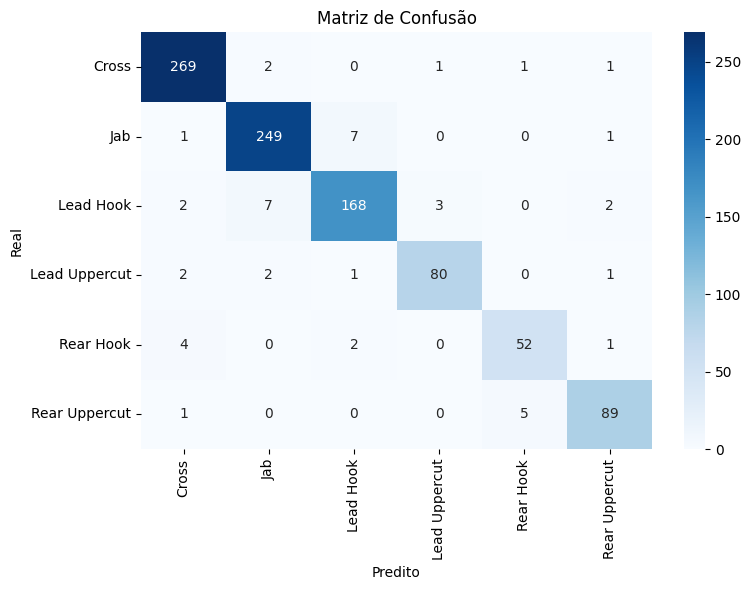

In [ ]:
# Avaliar
from tensorflow.keras.models import load_model

best_model = load_model("best_model_v2.keras")
y_pred = np.argmax(best_model.predict(X_te_feat), axis=1)

print(classification_report(y_te, y_pred, target_names=classes))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()

In [ ]:
model.save('modelo_boxe.keras')

<Figure size 640x480 with 0 Axes>